# CC full covariance

### Import libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv, det, pinv
from matplotlib.colors import LogNorm

In [2]:
dir_home = os.getcwd()
dir_data = dir_home+'/../data/'

### Define functions and fiducial Planck cosmology

In [3]:
def Hzmodel(params, z):
    H0, Omegam, w0, wa = params
    return H0*np.sqrt(Omegam*(1+z)**3+(1-Omegam)*(1+z)**(3.*(1+w0+wa))*np.exp(-3.*wa*(z/(1+z))))

In [4]:
zz=np.arange(0., 2., 0.01)
Omegam_fid=0.308
errOmegam_fid=0.012
H0_fid=67.8
errH0_fid=0.9
w0_fid=-1
wa_fid=0

s=[H0_fid,Omegam_fid,w0_fid,wa_fid]

### Load data

As a comparison, we show here the Planck (2018) LCDM cosmological model, together with CC data

Text(0, 0.5, 'H(z) [km/s/Mpc]')

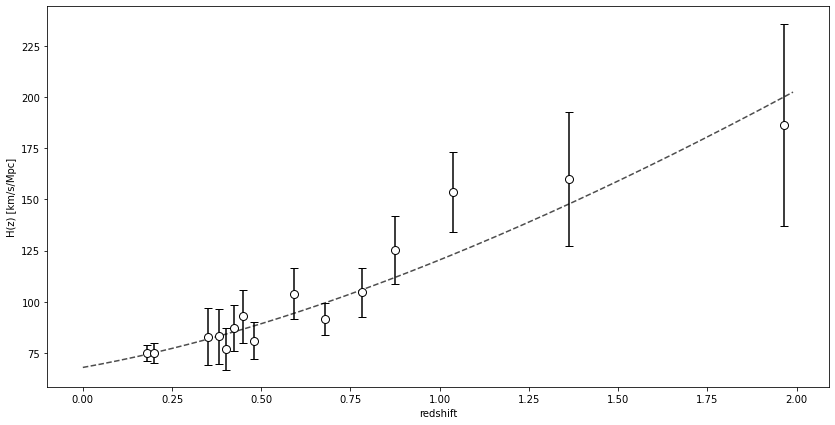

In [5]:
os.chdir(dir_data)
filename = 'HzTable_MM_BC03.dat'
z, Hz, errHz = np.genfromtxt(filename, comments='#', usecols=(0,1,2), unpack=True, delimiter=',')
ref = np.genfromtxt(filename, comments='#', usecols=(3), unpack=True, dtype=str, delimiter=',')

filename = 'data_MM20.dat'
zmod, imf, slib, sps, spsooo = np.genfromtxt(filename, comments='#', usecols=(0,1,2,3,4), unpack=True)
os.chdir(dir_home)

fig = plt.figure(figsize=(14,7))
plt.errorbar(z, Hz, errHz, fmt='o', color='k', mfc='white', elinewidth=1.5, ms=8, capsize=4)
plt.plot(zz, Hzmodel(s,zz), c='.3', ls='--', zorder=1)
plt.xlabel('redshift')
plt.ylabel('H(z) [km/s/Mpc]')

### Estimate CC covariance components

In [6]:
cov_mat_diag = np.zeros((len(z), len(z)), dtype='float64') 

for i in range(len(z)):
	cov_mat_diag[i,i] = errHz[i]**2

imf_intp = np.interp(z, zmod, imf)/100
slib_intp = np.interp(z, zmod, slib)/100
sps_intp = np.interp(z, zmod, sps)/100
spsooo_intp = np.interp(z, zmod, spsooo)/100

cov_mat_imf = np.zeros((len(z), len(z)), dtype='float64')
cov_mat_slib = np.zeros((len(z), len(z)), dtype='float64')
cov_mat_sps = np.zeros((len(z), len(z)), dtype='float64')
cov_mat_spsooo = np.zeros((len(z), len(z)), dtype='float64')

for i in range(len(z)):
	for j in range(len(z)):
		cov_mat_imf[i,j] = Hz[i] * imf_intp[i] * Hz[j] * imf_intp[j]
		cov_mat_slib[i,j] = Hz[i] * slib_intp[i] * Hz[j] * slib_intp[j]
		cov_mat_sps[i,j] = Hz[i] * sps_intp[i] * Hz[j] * sps_intp[j]
		cov_mat_spsooo[i,j] = Hz[i] * spsooo_intp[i] * Hz[j] * spsooo_intp[j]
        

### Estimate full CC covariance matrix, and its determinant

In [7]:
cov_mat = cov_mat_spsooo+cov_mat_imf+cov_mat_diag
inv_cov_mat = inv(cov_mat)
print("Determinant = {:.3e}".format(det(cov_mat)))

Determinant = 4.560e+33


### Show CC full covariance matrix

Text(0.5, 1.0, 'Covariance CC data')

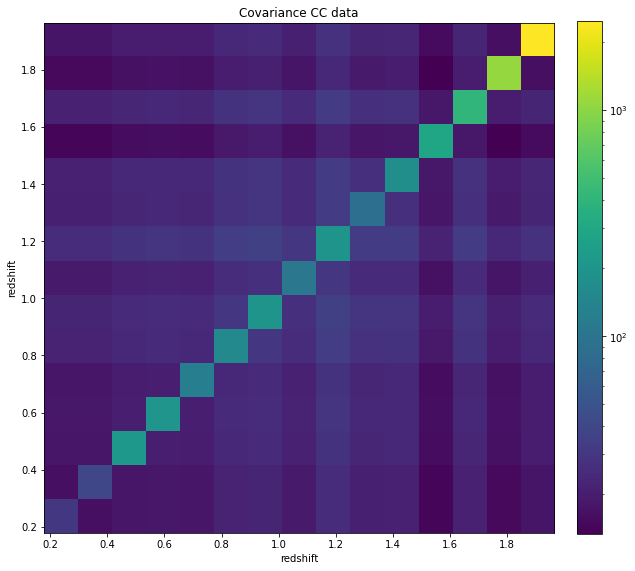

In [8]:
fig=plt.figure(figsize=(10,10))
cov = plt.imshow(cov_mat, interpolation='none', cmap=plt.cm.viridis, extent=[z.min(), z.max(), z.min(), z.max()], origin='lower', norm=LogNorm(vmin=cov_mat.min(),vmax=cov_mat.max()))
fig.colorbar(cov,fraction=0.046, pad=0.04)
plt.xlabel(r'redshift')
plt.ylabel(r'redshift')
plt.title(r'Covariance CC data')

### Show C*C^-1

To check that the covariance matrix is invertible, we estimated here it's inverse, and show C*C^-1

Text(0.5, 1.0, '$C\\cdot C^{-1}$')

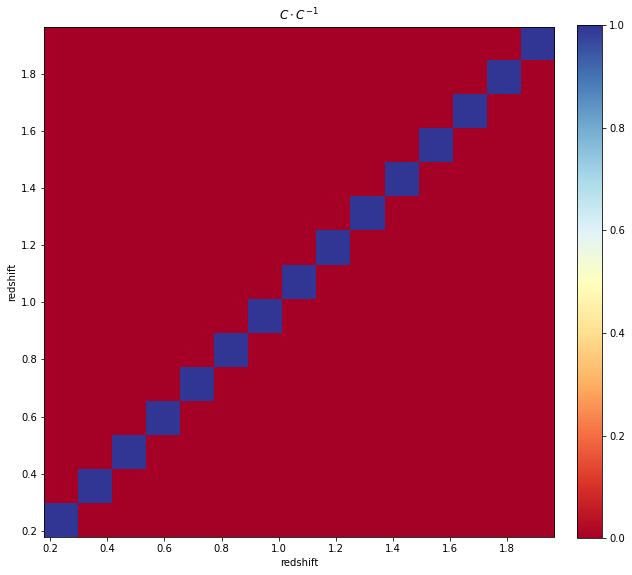

In [9]:
fig=plt.figure(figsize=(10,10))
cov = plt.imshow(np.dot(inv_cov_mat, cov_mat), interpolation='none', cmap=plt.cm.RdYlBu, extent=[z.min(), z.max(), z.min(), z.max()], origin='lower')
fig.colorbar(cov,fraction=0.046, pad=0.04)#, format='%.2f')
plt.xlabel(r'redshift')
plt.ylabel(r'redshift')
plt.title(r'$C\cdot C^{-1}$')
